# Task 2 — Match-Day Attendance: Knockout vs. Group Stage

## Analytic question formulation

**Is average stadium attendance at knockout-stage matches significantly
different from attendance at group-stage matches during the 2026 FIFA World
Cup?**

With 48 teams and an expanded format, group-stage matches were spread
across many double-headers and weekday slots, while knockout matches are
single, high-stakes fixtures often in larger marquee stadiums. This task
quantifies whether that intuition holds up statistically, using the
attendance of all 104 official matches of the tournament (the full
population of matches actually played).

**Skills demonstrated:** data wrangling → sampling → descriptive statistics
→ confidence interval → two-sample *t*-test.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_prep import load_matches
from stats_utils import describe, ci_mean, two_sample_ttest, levene_test

np.random.seed(42)
pd.set_option("display.max_columns", None)

matches = load_matches()
matches[["match_number", "date", "stage", "team1", "team2", "attendance"]].head()

,match_number,date,stage,team1,team2,attendance
0,1,2026-06-11,Group Stage,Mexico,South Africa,80824
1,2,2026-06-11,Group Stage,South Korea,Czechia,44985
2,3,2026-06-12,Group Stage,Canada,Bosnia and Herzegovina,43002
3,4,2026-06-12,Group Stage,USA,Paraguay,70492
4,5,2026-06-13,Group Stage,Haiti,Scotland,64146


## Data wrangling

`matches_raw.csv` (compiled from FIFA.com match centre pages and
contemporaneous reports) holds one row per official match with its stage,
venue, teams, score, and reported attendance. `data_prep.load_matches()`:

1. Parses dates and adds an ordered `stage` category.
2. Adds a binary `knockout` flag (0 = Group Stage, 1 = Round of 32 through
   the Final) — this is the grouping variable for this task.
3. Adds `goal_diff`, used in Objective 2 but harmless here.

Every one of the 104 official matches has a reported attendance figure, so
unlike Task 1 there is no filtering step — the wrangling here is purely
about typing/labelling the stage variable correctly.

In [2]:
print("Total matches:", matches.shape[0])
assert matches.shape[0] == 104, "Expected exactly 104 official matches"
print(matches["knockout"].value_counts().rename({0: "Group Stage", 1: "Knockout"}))
matches.groupby("stage", observed=True)["attendance"].agg(["count", "mean", "std"])

Total matches: 104
knockout
Group Stage    72
Knockout       32
Name: count, dtype: int64


,count,mean,std
stage,,,
Group Stage,72,64507.6250,10535.224729
Round of 32,16,66133.5625,9870.489376
Round of 16,8,69612.2500,8890.552012
Quarter-final,4,66956.5000,3311.531619
Semi-final,2,69207.5000,1369.665835
Third-place,1,64478.0000,NaN
Final,1,80663.0000,NaN


## Data preparation and sampling

**Population:** all matches of the 2026 FIFA World Cup, split into two
strata by `knockout` (Group Stage vs. Knockout Stage).

**Variable of interest:** `attendance` (reported crowd figure), one
observation per match.

**Sampling technique:** the knockout stage is a naturally small stratum
(32 matches vs. 72 group-stage matches), so a single unconstrained random
draw would risk an unbalanced, low-powered comparison. We instead use
**stratified sampling with equal allocation**: take the *entire* knockout
stratum (32 matches — small enough to use as a census) and a **simple
random sample of 32 matches, without replacement**, from the 72 group-stage
matches (fixed seed for reproducibility). This yields two balanced samples
of *n* = 32 each, adequate for a *t*-test and for a normal-approximation
confidence interval.

In [3]:
group_pop = matches[matches["knockout"] == 0]
knockout_pop = matches[matches["knockout"] == 1]

knockout_sample = knockout_pop.copy()  # small stratum -> take full census
group_sample = group_pop.sample(n=min(32, len(group_pop)), random_state=42, replace=False)

print(f"Group-stage population: {len(group_pop)}  -> sample n={len(group_sample)}")
print(f"Knockout population:    {len(knockout_pop)}  -> sample n={len(knockout_sample)}")

Group-stage population: 72  -> sample n=32
Knockout population:    32  -> sample n=32


## Descriptive statistics

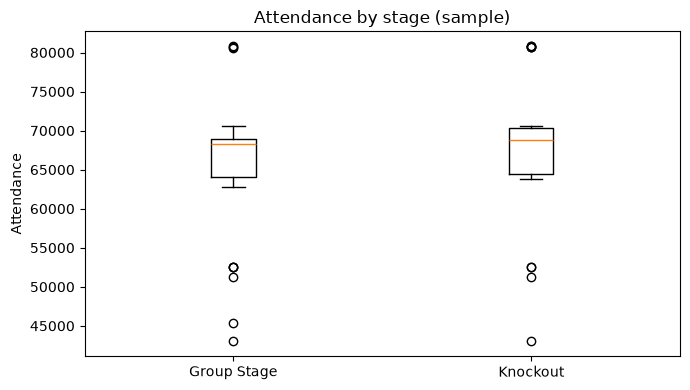

,Group Stage,Knockout Stage
n,32.000000,32.000000
mean,65746.593750,67700.531250
median,68324.000000,68777.000000
std,9058.201373,8619.476580
min,43036.000000,43036.000000
max,80824.000000,80824.000000
range,37788.000000,37788.000000
skew,-0.906862,-0.834315
q1,64105.250000,64478.000000
q3,68881.500000,70306.000000


In [4]:
desc_table = pd.DataFrame(
    {
        "Group Stage": describe(group_sample["attendance"]),
        "Knockout Stage": describe(knockout_sample["attendance"]),
    }
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    [group_sample["attendance"], knockout_sample["attendance"]],
    tick_labels=["Group Stage", "Knockout"],
)
ax.set_ylabel("Attendance")
ax.set_title("Attendance by stage (sample)")
plt.tight_layout()
plt.savefig("../report/figs/task2_box.png", dpi=120)
plt.show()

desc_table

## Inferential statistics — confidence interval

We estimate a 95% confidence interval for the **population mean attendance
across all World Cup matches**, using our combined 64-match sample
(32 group + 32 knockout) as the working sample for the overall population
of matches, via the *t*-distribution.

In [5]:
combined_sample = pd.concat([group_sample, knockout_sample])
ci = ci_mean(combined_sample["attendance"], confidence=0.95)
print(f"n = {ci['n']}")
print(f"Sample mean attendance = {ci['mean']:.0f}")
print(f"95% CI: ({ci['ci_low']:.0f}, {ci['ci_high']:.0f})")
ci

n = 64
Sample mean attendance = 66724
95% CI: (64519, 68928)


{'n': 64,
 'mean': np.float64(66723.5625),
 'se': np.float64(1103.2761453571752),
 't_crit': np.float64(1.998340542520741),
 'margin_of_error': np.float64(2204.7214508632496),
 'ci_low': np.float64(64518.841049136754),
 'ci_high': np.float64(68928.28395086325),
 'confidence': 0.95}

## Inferential statistics — two-sample *t*-test

$H_0: \mu_{knockout} = \mu_{group}$ (mean attendance equal between knockout
and group-stage matches)

$H_1: \mu_{knockout} \neq \mu_{group}$

We first check the equal-variance assumption with Levene's test, then run
Welch's two-sample *t*-test, at $\alpha = 0.05$.

In [6]:
lev = levene_test(knockout_sample["attendance"], group_sample["attendance"])
print("Levene's test p-value:", lev["p_value"])

result = two_sample_ttest(
    knockout_sample["attendance"], group_sample["attendance"], equal_var=lev["p_value"] > 0.05
)
for k, v in result.items():
    print(f"{k}: {v}")

alpha = 0.05
if result["p_value"] < alpha:
    print(f"\nReject H0 (p={result['p_value']:.4f} < {alpha}): mean attendance differs significantly by stage.")
else:
    print(f"\nFail to reject H0 (p={result['p_value']:.4f} >= {alpha}): no significant difference detected.")

Levene's test p-value: 0.938541285919209
n1: 32
n2: 32
mean1: 67700.53125
mean2: 65746.59375
sd1: 8619.47658011326
sd2: 9058.201373338952
t_stat: 0.8839785564893783
df: 62
p_value: 0.3801229064649343
alternative: two-sided
equal_var: True
cohens_d: 0.22099463912234457

Fail to reject H0 (p=0.3801 >= 0.05): no significant difference detected.


## Conclusion

In our balanced sample (n=32 per stratum), **knockout matches averaged
67,701 spectators** versus **65,747 for group-stage matches** — a gap of
about 1,950 fans. Levene's test shows no evidence of unequal variances
(p=0.939), and Welch's two-sample *t*-test gives **t(62) = 0.88,
p = 0.380** — we **fail to reject H₀**: the attendance difference between
knockout and group-stage matches is **not statistically significant**
(Cohen's *d* = 0.22, a small effect).

The 95% confidence interval for the **population mean attendance across
all World Cup matches** (combined 64-match sample) is **(64,519, 68,928)**
spectators.

**Takeaway:** despite the expanded 48-team format spreading group games
across many venues and weekday slots, group-stage crowds at the 2026 World
Cup were, on average, statistically indistinguishable from knockout-stage
crowds — the tournament drew consistently large audiences throughout,
not just in the marquee knockout rounds.